# TP4 : Séparations de sources avec un Unet

Author : 
- Adjal Massyl

# 0. Import des librairies

In [15]:
# import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import random
import librosa
import librosa.display
import musdb

%load_ext autoreload
%autoreload 2

from config import SEED, DATASET_PATH, AudioConfig

# print(os.getcwd())
random.seed(SEED)

from data import data_feeder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Article

## Petite overview de l'article généré par un LLM :  

### I. Prérequis Académiques

Pour saisir toutes les subtilités de cet article, il faut posséder des bases solides dans trois domaines principaux :

**1. Traitement du Signal Audio (DSP)**
* **Spectrogrammes :** Comprendre ce qu'est un spectrogramme (représentation temps-fréquence) et la différence entre **Magnitude** (amplitude) et **Phase**. L'article repose entièrement sur la manipulation de spectrogrammes de magnitude[cite: 74, 93].
* **Transformée de Fourier à Court Terme (STFT) :** Savoir comment on passe d'un signal audio brut (forme d'onde) à un spectrogramme, et inversement (iSTFT). L'article utilise une fenêtre de 1024 et un saut (hop) de 768 frames[cite: 89].
* **Masquage Temps-Fréquence :** Comprendre le concept de "masque binaire" ou "masque souple" (soft mask) appliqué à un spectrogramme pour filtrer une source spécifique[cite: 43, 44].

**2. Apprentissage Profond (Deep Learning)**
* **Réseaux de Neurones Convolutifs (CNN) :** Comprendre les couches de convolution, le *stride* (pas), le *padding*, et les fonctions d'activation (ReLU, Leaky ReLU)[cite: 85].
* **Architecture Encodeur-Décodeur :** Comprendre comment un réseau compresse l'information (encodage) puis la reconstruit (décodage)[cite: 62].
* **Fonctions de Coût (Loss Functions) :** Notamment la norme L1 et L1,1 utilisée ici pour minimiser l'erreur entre le masque prédit et le masque réel[cite: 77, 78].
* **Surapprentissage et Régularisation :** Comprendre l'utilité du *Dropout* (utilisé à 50% dans ce modèle) et de la *Batch Normalization*[cite: 86].

**3. Mathématiques**
* **Algèbre Linéaire :** Opérations matricielles (multiplication élément par élément, normes).

---

### II. Explication Détaillée de l'Article

L'objectif de l'article est de séparer la **voix chantée** de l'**accompagnement instrumental** dans un enregistrement musical mono[cite: 31]. Les auteurs traitent ce problème comme une tâche de **traduction image-à-image**[cite: 22].

#### 1. L'Architecture : Le U-Net
L'innovation centrale est l'adaptation de l'architecture **U-Net** (créée pour la segmentation d'images biomédicales) à l'audio[cite: 59, 60].


* **Structure en "U" :** Le réseau a une forme d'encodeur (qui réduit la dimension spatiale de l'image pour capturer le contexte global) suivi d'un décodeur (qui augmente la dimension pour retrouver la résolution d'origine)[cite: 62, 63].
* **Le problème des CNN classiques :** Dans les réseaux encodeur-décodeur classiques (type "sablier"), la compression fait perdre les détails fins. Or, en audio, une petite erreur de reconstruction fréquentielle ou temporelle s'entend très distinctement (artefacts)[cite: 65, 66].
* **La solution (Skip Connections) :** Le U-Net ajoute des **connexions de saut** (skip connections) qui relient directement les couches de l'encodeur aux couches correspondantes du décodeur. Cela permet de transférer les informations de bas niveau (détails fins) directement vers la sortie, sans passer par goulot d'étranglement de la compression[cite: 68, 69].

#### 2. La Méthodologie
* **Entrée :** Le spectrogramme de magnitude du mélange audio (Mix).
* **Sortie :** Un "masque" (valeurs entre 0 et 1) prédit par le réseau.
* **Reconstruction :** Ce masque est multiplié par le spectrogramme d'entrée pour isoler la voix (ou l'instrumental). Pour reconstruire le son, ils utilisent la **phase du signal original**, car le réseau ne prédit que la magnitude[cite: 93].
* **Entraînement :** Ils entraînent deux modèles séparés : un pour isoler la voix, un pour isoler les instruments[cite: 72].

#### 3. Le "Hack" du Dataset (Données d'entraînement)
Le manque de données (pistes séparées voix/instruments) est un problème majeur dans ce domaine[cite: 48]. Les auteurs ont contourné ce problème de manière astucieuse :
* Ils ont récupéré des paires de chansons commerciales : la version "Originale" et la version "Instrumentale" officielle[cite: 98, 100].
* En soustrayant l'instrumental de l'original, ils ont obtenu une approximation de la piste vocale[cite: 166].
* Cela leur a permis de créer un dataset massif de **20 000 titres** (environ 2 mois d'audio continu), ce qui était le plus grand à l'époque[cite: 168, 169].

#### 4. Évaluation et Résultats
Ils ont comparé leur modèle U-Net à deux autres modèles : un **modèle de base** (même architecture mais sans les skip connections) et **Chimera** (l'état de l'art de l'époque)[cite: 173, 176].

* **Métriques Objectives :** Ils ont utilisé les mesures standards (SDR, SIR, SAR) sur les datasets publics iKala et MedleyDB. Le U-Net a surpassé les autres modèles sur toutes les métriques[cite: 218].
* **Visualisation :** Ils montrent que le modèle sans skip connections capture la structure globale mais perd les détails fins (spectrogramme flou), alors que le U-Net génère des détails précis[cite: 223].
* **Évaluation Subjective :** Ils ont fait écouter les extraits à des humains via la plateforme CrowdFlower. Les auditeurs ont jugé la qualité sonore et la séparation du U-Net supérieures à celles des autres modèles[cite: 305].

#### 5. Conclusion
L'article conclut que l'architecture U-Net est très efficace pour la séparation de sources grâce à sa capacité à préserver les détails fins via les skip connections, et que l'utilisation d'un grand dataset de qualité commerciale est cruciale pour la généralisation du modèle[cite: 307, 311].


# 2. Lecture des Données

In [16]:
# Add FFmpeg to path
# os.environ["PATH"] += os.pathsep + r"C:\Users\adjal\miniconda3\envs\Son_TP4\Library\bin"

# Load the DB using the 'root' argument (We set download=False because we already have the files)
mus = musdb.DB(root=DATASET_PATH, download=False)

# Test
print(f"Success! Loaded {len(mus)} tracks.")
print(mus[0].audio.shape)

Success! Loaded 144 tracks.
(300032, 2)


In [17]:
# test database

import IPython.display as ipd

# Pick the first track
track = mus[2]
print(f"Track Name: {track.name}")

# Access a specific stem (options: 'vocals', 'drums', 'bass', 'other', 'accompaniment')
vocals = track.targets['vocals'].audio

# Play the first 5 seconds of the vocals (Stereo)
# Note: Audio is (samples, channels), so we transpose it for some players if needed, but IPython handles (2, N) or (N, 2) usually fine.
print("Playing Vocals...")
time = 5
ipd.display(ipd.Audio(vocals[:(track.rate)*time].T, rate=track.rate))

Track Name: ANiMAL - Easy Tiger
Playing Vocals...


## mus structure

The `mus` object you created is an instance of the **`musdb.DB`** class. It acts as the "container" for your entire music dataset, allowing you to iterate through tracks and access their audio data easily.

Here is the structural breakdown of what is inside this object.

### **1. The Object Hierarchy**

Think of `mus` as a specialized Python list. It contains a list of **Tracks**, and each **Track** contains the audio **Mixture** and the isolated **Stems** (Targets).

```text
mus (DB Object)
│
├── tracks (List of MultiTrack objects)
│   ├── mus[0] (Track: "Artist - Title")
│   │   ├── audio  (Numpy Array: The full stereo mix)
│   │   ├── rate   (Int: Sample rate, e.g., 44100)
│   │   ├── name   (String: Track name)
│   │   │
│   │   └── targets (Dictionary of stems)
│   │       ├── 'vocals' (Source Object) ───> .audio (Numpy Array)
│   │       ├── 'drums'  (Source Object) ───> .audio (Numpy Array)
│   │       ├── 'bass'   (Source Object) ───> .audio (Numpy Array)
│   │       ├── 'other'  (Source Object) ───> .audio (Numpy Array)
│   │       └── 'accompaniment' (Computed) ─> .audio (Numpy Array)
│   │
│   ├── mus[1]
│   └── ...

```

---

### **2. Key Attributes of a Track**

When you access a single track (e.g., `track = mus[0]`), you are working with a `MultiTrack` object. Here are its most important properties:

#### **A. The Mixture (`track.audio`)**

* **What it is:** The original full song (all instruments mixed together).
* **Data Type:** Numpy Array.
* **Shape:** `(samples, 2)` (Stereo).
* **Usage:** This is your **input** `x` for any source separation model.

#### **B. The Targets (`track.targets`)**

* **What it is:** A dictionary containing the isolated instruments (Ground Truth).
* **Keys:**
* `'vocals'`: Only the singing voice.
* `'drums'`: Percussion.
* `'bass'`: Bass guitar/synth.
* `'other'`: Everything else (piano, guitar, strings, etc.).
* `'accompaniment'`: A special target automatically calculated as `mixture - vocals`. This is useful if you are just training a "Karaoke" remover.


* **Usage:** These are your **expected outputs** `y`.

#### **C. The Stems Tensor (`track.stems`)**

* **What it is:** A massive 3D array containing *all* sources stacked together.
* **Shape:** `(5, samples, 2)`
* **Order:** `[Mixture, Drums, Bass, Other, Vocals]`

---

### **3. Practical Examples**

Here is how you actually use this structure in your code:

**Example 1: Accessing the Mixture (Input)**

```python
track = mus[0]

# Get the full mixture audio
mix_audio = track.audio
print(mix_audio.shape)  # Output: (308700, 2)  <- 7 seconds at 44.1kHz

```

**Example 2: Accessing a Specific Stem (Target)**

```python
# Get just the vocals
vocals_audio = track.targets['vocals'].audio

# Get just the drums
drums_audio = track.targets['drums'].audio

```

**Example 3: Accessing Metadata**

```python
print(track.name)    # e.g., "A Classic Education - NightOwl"
print(track.rate)    # 44100
print(track.subset)  # 'train' or 'test'

```

# 3. Data Feeder (Géneration des Données)

Article : 3.1.2 Network Architecture Details 

"
Given the heavy computational requirements of train-
ing such a model, we first downsample the input audio to
8192 Hz in order to speed up processing. We then com-
pute the Short Time Fourier Transform with a window size
of 1024 and hop length of 768 frames, and extract patches
of 128 frames (roughly 11 seconds) that we feed as input
and targets to the network. The magnitude spectrograms
are normalized to the range [0, 1].
"

In [18]:
# Paramatres de l'Article Singing_voice_separation_with_Unet_2017.pdf :

sample_duration = AudioConfig.num_frames * (AudioConfig.hop_length/AudioConfig.sample_rate)
print(f"sample duration : {sample_duration} s")

sample duration : 6.0 s


Génération en cours...
fetching new track
fetching new track
Type de x : <class 'numpy.ndarray'>
Forme de x (Shape) : (2, 512, 64, 1)
Forme de y (Shape) : (2, 512, 64, 1)


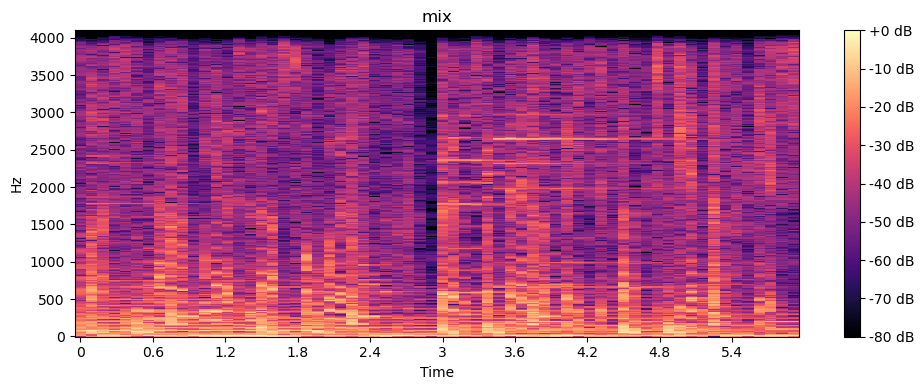

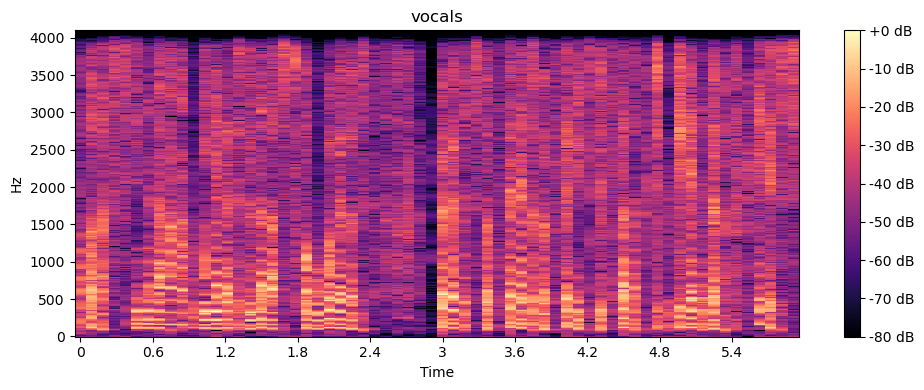

In [19]:
# test the feeder

# init feeder
test_feeder = data_feeder(mus, audio_config=AudioConfig , batch_size=2)

# On demande manuellement le premier batch
print("Génération en cours...")
batch_x, batch_y = next(test_feeder) 

# Vérification des dimensions
print(f"Type de x : {type(batch_x)}")
print(f"Forme de x (Shape) : {batch_x.shape}") 
print(f"Forme de y (Shape) : {batch_y.shape}")



def display_spectrogram(spec, sr, hop_length, title="Spectrogram", to_db=True):
    """
    Displays a spectrogram with proper axes and scaling.
    
    Args:
        spec (np.array): Input spectrogram of shape (Freq, Time) or (Freq, Time, 1)
        title (str): Title of the plot
        sr (int): Sampling rate (default 8192Hz per Article)
        hop_length (int): Hop length (default 768 per Article)
        to_db (bool): If True, converts magnitude to decibels for display
    """
    plt.figure(figsize=(10, 4))
    
    # 1. Handle Dimensions: Remove the channel dimension (512, 12, 1) -> (512, 12)
    if spec.ndim == 3:
        spec = spec.squeeze()
    
    # 2. Convert to Decibels (Log Scale)
    # The network works on magnitude [0, 1], but humans see audio logarithmically.
    if to_db:
        # ref=np.max sets the maximum value to 0 dB (standard for audio)
        spec_to_plot = librosa.amplitude_to_db(spec, ref=np.max)
    else:
        spec_to_plot = spec

    # 3. Display using Librosa (handles axes automatically)
    librosa.display.specshow(
        spec_to_plot,
        sr=sr,
        hop_length=hop_length,
        x_axis='time',
        y_axis='hz', # Use 'log' for log-frequency axis if preferred
        cmap='magma' # 'magma' or 'inferno' are good for spectrograms
    )
    
    plt.colorbar(format='%+2.0f dB' if to_db else '%+2.0f')
    plt.title(title)
    plt.tight_layout()
    plt.show()


# hear
mix = batch_x[0]
vocals = batch_y[0]
time = 5
display_spectrogram(mix, AudioConfig.sample_rate, AudioConfig.hop_length, title="mix")
display_spectrogram(vocals, AudioConfig.sample_rate, AudioConfig.hop_length, title="vocals")